# 04 - PCA: Dimensionality Reduction

Goal: summarize Spotify audio characteristics into fewer principal components while retaining at least 90% of the variance.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="Set2")
df = pd.read_csv(DATA_CLEAN)
print(df.shape)

(89741, 23)


## Standardization Before PCA

PCA is scale-sensitive. Features like `tempo` and `duration_min` have larger units than bounded features like `danceability`, so all inputs are standardized to mean 0 and standard deviation 1 before PCA.

In [3]:
pca_features = [
    "duration_min", "is_explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature"
]

X = df[pca_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_components_90 = int(np.argmax(cumulative >= 0.90) + 1)
print(f"Components needed for at least 90% variance: {n_components_90}")

Components needed for at least 90% variance: 11


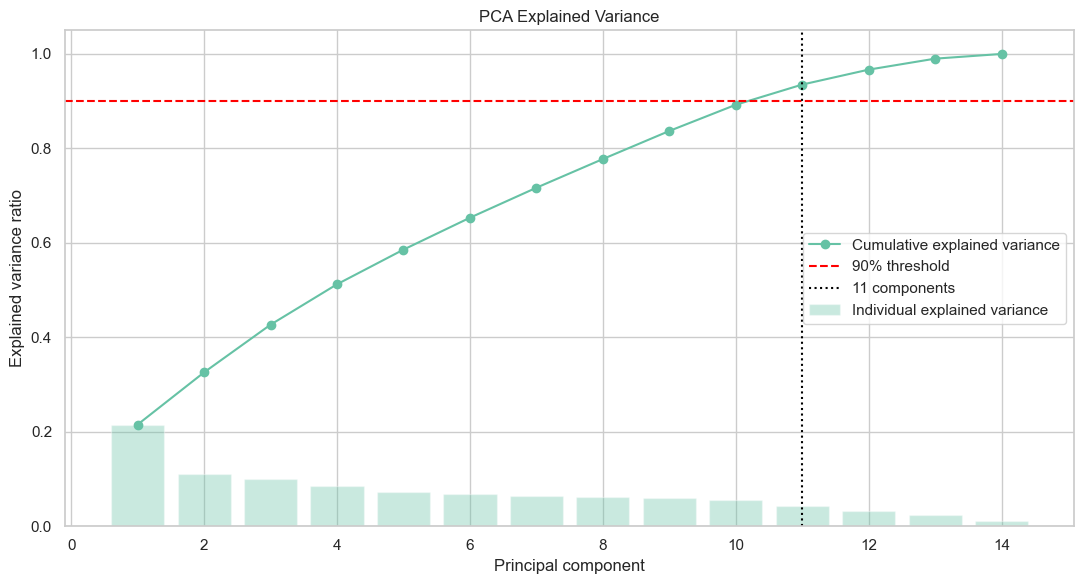

In [4]:
plt.figure(figsize=(11, 6))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o", label="Cumulative explained variance")
plt.bar(range(1, len(explained) + 1), explained, alpha=0.35, label="Individual explained variance")
plt.axhline(0.90, color="red", linestyle="--", label="90% threshold")
plt.axvline(n_components_90, color="black", linestyle=":", label=f"{n_components_90} components")
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

## Component Loadings

Loadings show which original variables dominate each principal component. Large absolute values mean the variable contributes strongly to that component.

In [5]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[f"PC{i}" for i in range(1, len(pca_features) + 1)]
)
display(loadings.iloc[:, :n_components_90].round(3))

influential = {}
for pc in loadings.columns[: min(5, n_components_90)]:
    influential[pc] = loadings[pc].abs().sort_values(ascending=False).head(5).index.tolist()
display(pd.DataFrame(dict([(k, pd.Series(v)) for k, v in influential.items()])))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
duration_min,-0.009,-0.403,-0.030,-0.140,-0.225,0.570,-0.002,0.412,0.467,-0.210,-0.037
is_explicit,0.125,0.205,0.462,-0.224,-0.418,-0.257,-0.105,0.249,-0.095,-0.137,-0.569
danceability,0.265,0.421,-0.246,-0.264,-0.168,0.175,-0.060,-0.005,0.223,0.269,-0.050
energy,0.486,-0.272,0.092,0.059,0.031,0.014,-0.106,-0.067,-0.088,0.187,0.058
key,0.046,-0.038,0.006,-0.496,0.571,-0.078,0.262,0.533,-0.210,0.146,-0.005
loudness,0.496,-0.097,-0.022,0.112,0.063,-0.020,-0.180,0.055,-0.112,-0.119,0.098
mode,-0.053,0.112,-0.048,0.627,-0.216,0.041,0.157,0.576,-0.199,0.375,0.039
speechiness,0.110,0.227,0.597,-0.132,-0.137,0.016,0.152,0.001,0.216,0.165,0.647
acousticness,-0.419,0.350,0.029,0.051,0.103,0.049,0.216,0.013,0.156,-0.204,0.000
instrumentalness,-0.272,-0.329,-0.018,-0.251,-0.234,-0.035,0.094,-0.219,0.016,0.693,-0.149


,PC1,PC2,PC3,PC4,PC5
0,loudness,valence,speechiness,mode,key
1,energy,danceability,liveness,key,is_explicit
2,acousticness,duration_min,is_explicit,danceability,time_signature
3,valence,acousticness,valence,liveness,liveness
4,instrumentalness,instrumentalness,danceability,instrumentalness,instrumentalness


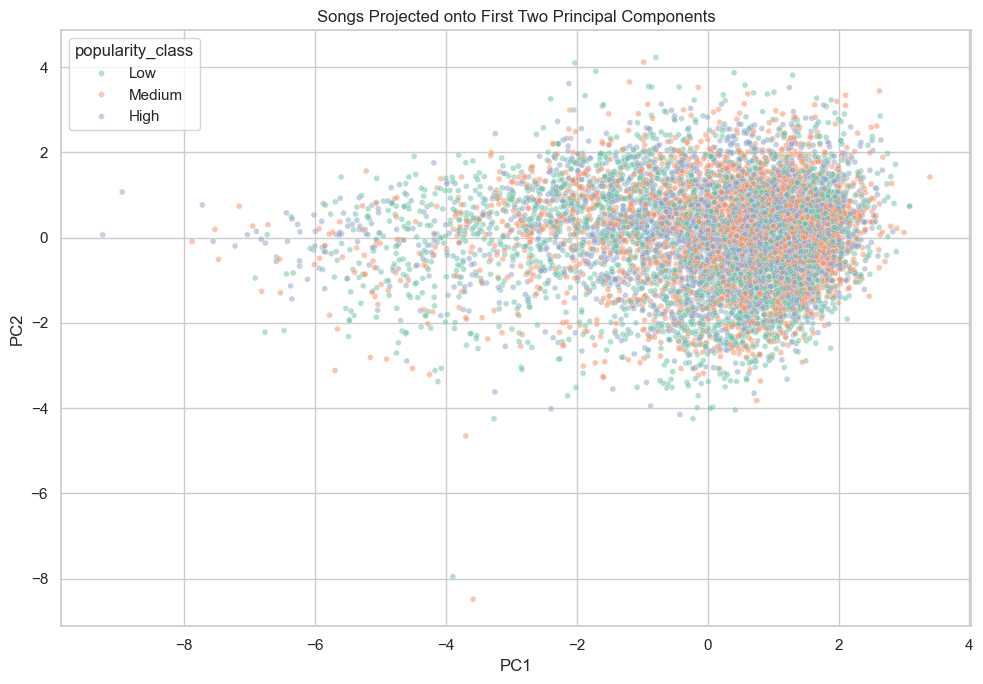

In [6]:
sample_idx = df.sample(n=min(8000, len(df)), random_state=RANDOM_STATE).index
pca_plot = pd.DataFrame(X_pca[sample_idx, :3], columns=["PC1", "PC2", "PC3"])
pca_plot["popularity_class"] = df.loc[sample_idx, "popularity_class"].values
pca_plot["track_genre"] = df.loc[sample_idx, "track_genre"].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_plot, x="PC1", y="PC2", hue="popularity_class", alpha=0.5, s=18)
plt.title("Songs Projected onto First Two Principal Components")
plt.tight_layout()
plt.show()

In [7]:
print("Answers:")
print("- Variables that dominate the structure are the features with the largest absolute loadings in the first principal components.")
for pc, vars_ in influential.items():
    print(f"  {pc}: {', '.join(vars_)}")
print(f"- Dimensionality reduction to {n_components_90} components is feasible for retaining at least 90% of numeric audio-feature variance.")
print("- A 2D PCA plot is useful for visualization, but it does not retain all information; the 90% component count is better for modeling compression.")

Answers:
- Variables that dominate the structure are the features with the largest absolute loadings in the first principal components.
  PC1: loudness, energy, acousticness, valence, instrumentalness
  PC2: valence, danceability, duration_min, acousticness, instrumentalness
  PC3: speechiness, liveness, is_explicit, valence, danceability
  PC4: mode, key, danceability, liveness, instrumentalness
  PC5: key, is_explicit, time_signature, liveness, instrumentalness
- Dimensionality reduction to 11 components is feasible for retaining at least 90% of numeric audio-feature variance.
- A 2D PCA plot is useful for visualization, but it does not retain all information; the 90% component count is better for modeling compression.
